# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Gigih Dwi Kartika Chandra Wibowo]
- **Email:** [cdcc201d6y2384@student.devacademy.id]
- **ID Dicoding:** [CDCC201D6Y2384]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Berdasarkan tren pertumbuhan volume penyewaan bulanan selama 12 bulan terakhir, bagaimana prediksi kebutuhan armada sepeda untuk kuartal mendatang, dan langkah operasional apa yang harus diprioritaskan untuk mengantisipasi potensi lonjakan atau penurunan permintaan tersebut?

- Pertanyaan 2: Bagaimana karakteristik perilaku penyewaan sepeda selama semester pertama tahun 2012 dapat diklasifikasikan ke dalam empat klaster perilaku (Low, Commuter, Leisure, Hybrid), dan kebijakan operasional apa yang dapat dirancang berdasarkan pergeseran pola klaster tersebut untuk mengoptimalkan pendapatan serta retensi pengguna?

- Pertanyaan 3: Sejauh mana hubungan korelasi antara variabel suhu yang dirasakan (atemp) dan kecepatan angin (windspeed) memengaruhi volume penyewaan sepeda selama jam sibuk di hari kerja pada kuartal kedua tahun 2012, dan bagaimana temuan ini dapat digunakan untuk menentukan kebijakan penyesuaian ketersediaan sepeda di titik-titik tertentu?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

**Insight (day.csv dan hour.csv):**
- day.csv: Data agregat harian.
- hour.csv: Data yang lebih detail dari setiap jamnya
- instant: indeks urutan baris data.
- season: Musim (1: Semi, 2: Panas, 3: Gugur, 4: Dingin).
- yr: Tahun (0: 2011, 1: 2012).
- mnth: Bulan (1 hingga 12).
- hr: Jam (0 hingga 23)
- holiday: Apakah hari tersebut hari libur (1) atau bukan (0).
- weekday: Hari dalam seminggu.
- workingday: Apakah hari tersebut hari kerja (1) atau akhir pekan (0)
- weathersit: 1: Cerah, sedikit berawan; 2: Berkabut + Berawan,   berkabut; 3: Salju ringan, hujan ringan; 4: Hujan deras + badai petir.
- temp: Suhu udara yang dinormalisasi dalam derajat Celsius.
- atemp: Suhu yang "dirasakan" oleh manusia (feeling temperature) yang dinormalisasi.
- hum: Kelembapan udara yang dinormalisasi.
- windspeed: Kecepatan angin yang dinormalisasi.
- casual: Jumlah pengguna tidak terdaftar (pengguna sesekali).
- registered: Jumlah pengguna terdaftar (member).
- cnt: Total penyewaan sepeda (casual + registered).

- pada tahap Gathering data, saya mendapatkan wawasan dari dua dataset yang dependen ini bahwa merupakan dataset penyewaan sepeda yang dilakukan penjejakan pada pengguna casual dan pengguna registered yang menggunakan unit-unit sepeda tersebut pada rentang waktu dua tahun. dua dataset ini menunjukan bahwa terdapat pengaruh antara kondisi cuaca, suhu, dan musim dalam aktivitas penggunaan sepeda selama tahun 2011 hingga 2012.

### Assessing Data

In [3]:
# menampilkan info dari dataset
hour_df.info()
day_df.info()

#menampilkan deskripsi statistik dari dataset
hour_df.describe()
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

- insight yang saya temukan dari tahap assesing data dua dataset ini adalah tidak ditemukan missing value dan duplikasi data.
- saya mendapatkan insight bahwa terdapat type data yang inconsistent yaitu pada konten di kolom "dteday", type data saat ini adalah object. seharusnya adalah typoe data datetime agar memperkuat keterangan waktu.

### Cleaning Data

In [4]:
# mengubah type data pada kolom "dteday" menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

**Insight:**
- kolom "dteday" pada kedua dataset telah diubah type datanya menjadi datetime agar bisa dilakukan operasi time series, sehingga data sudah bersih dan siap untuk dilakukan EDA.

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# menjawab pertanyaan nomor 1
monthly_trend = day_df.resample(rule='ME', on='dteday').agg({'cnt': 'sum'})
monthly_trend.index = monthly_trend.index.strftime('%Y-%m')



# menjawab pertanyaan nomor 2
# menyiapkan pembuatan empat klaster menggunakan median pengguna sepeda harian
median_cnt = day_df['cnt'].median()

# logika if, elif, else untuk menentukan setiap klaster berdasarkan jumlah pengguna casual dan registered
def categorize_day_4(row):
    if row['cnt'] < median_cnt:
        return 'Low_Usage'
    elif row['registered'] > row['casual'] * 2:
        return 'Commuter_Day'
    elif row['casual'] > row['registered']:
        return 'Leisure_Day'
    else:
        return 'Hybrid_Day'

# memfilter data enam bulan awal pada tahun 2012
h1_2012 = day_df[(day_df['dteday'].dt.year == 2012) & (day_df['dteday'].dt.month <= 6)].copy()
h1_2012['day_cluster'] = h1_2012.apply(categorize_day_4, axis=1)

# membuat function agregasi atau distribusi dari setiap klaster
cluster_distribution = h1_2012.groupby([h1_2012['dteday'].dt.month, 'day_cluster']).size().unstack(fill_value=0)



# menjawab pertanyaan nomor 3
# Filter dataset untuk kuartal kedua, hari kerja, dan jam-jam sibuk
q2_peak_hours = hour_df[
    (hour_df['mnth'].isin([4, 5, 6])) &
    (hour_df['workingday'] == 1) &
    (hour_df['hr'].isin([7, 8, 9, 16, 17, 18]))
].copy()


**Insight:**
- menyiapkan function yang dibutuhkan untuk menjawab pertanyaan-pertanyaan EDA, serta agar memudahkan melakukan visualisasi data
- membuat logika untuk mengkategorikan data menjadi empat klaster
- klaster "Commuter Day": Hari dengan jumlah registered sangat tinggi, dan casual rendah.
- klaster "Leisure Day": Hari dengan jumlah casual tinggi dan registered rendah.
- klaster "Low-Usage Day": Hari dengan kedua nilai rendah.
- klaster "High-Activity Day": Hari dengan kedua nilai tinggi.
- pada tahap EDA ini, saya mendapatkan insight yang mungkin untuk disimpulkan menjadi pertanyaan-pertanyaan EDA dari dua dataset yang telah bersih ini.
- tahapan ini berisi function-function yang telah dibuat untuk menjawab tiga pertanyaan di atas dan untuk mempersiapkan visualisasi data.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berdasarkan tren pertumbuhan volume penyewaan bulanan selama 12 bulan terakhir, bagaimana prediksi kebutuhan armada sepeda untuk kuartal mendatang, dan langkah operasional apa yang harus diprioritaskan untuk mengantisipasi potensi lonjakan atau penurunan permintaan tersebut?

- menurut saya pertanyaan ini memenuhi metode SMART
- Specific: fokus pada volume penyewaan dan langkah operasional.
- Measurable: bisa diukur menggunakan data numerik dari kolom cnt.
- Achievable: bisa dicapai dengan menghitung tren historis (rata-rata atau time-series analysis).
- Relevant: relevan untuk manajer operasional dalam mengelola inventaris.
- Time-bound: Jelas batasan waktunya ("12 bulan terakhir" dan "kuartal mendatang").

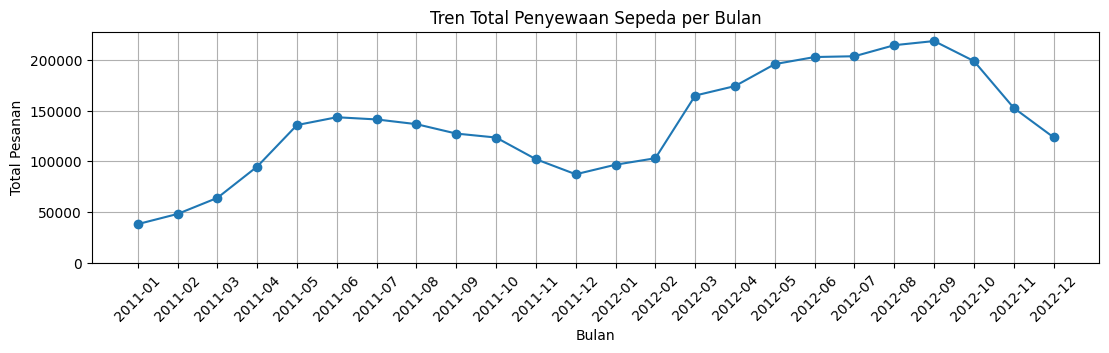

In [6]:
# Visualisasi
plt.figure(figsize=(13, 3))
plt.plot(monthly_trend.index, monthly_trend['cnt'], marker='o', linestyle='-')
plt.title('Tren Total Penyewaan Sepeda per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Pesanan')
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.grid(True)

# menampilkan diagram
plt.show()

### Pertanyaan 2: Bagaimana karakteristik perilaku penyewaan sepeda selama semester pertama tahun 2012 dapat diklasifikasikan ke dalam empat klaster perilaku (Low, Commuter, Leisure, Hybrid), dan kebijakan operasional apa yang dapat dirancang berdasarkan pergeseran pola klaster tersebut untuk mengoptimalkan pendapatan serta retensi pengguna?

- menurut saya pertanyaan ini memenuhi metode SMART
- Specific: menentukan klasifikasi menjadi empat klaster perilaku pengguna.
- Measurable: bisa diukur dengan membagi data pengguna (casual dan registered) berdasarkan ambang batas tertentu untuk setiap klaster.
- Achievable: dataset menyediakan informasi cukup untuk melakukan segmentasi ini.
- Relevant: relevan untuk strategi pemasaran dan retensi customer.
- Time-bound: dibatasi pada "semester pertama tahun 2012".

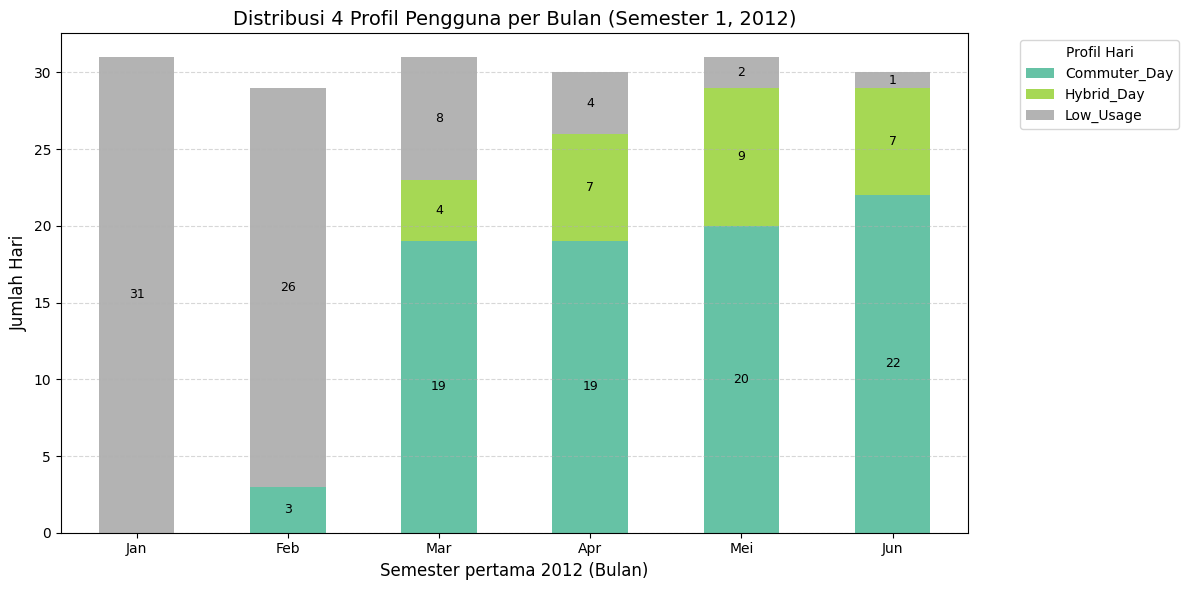

In [7]:
# membuat visualisasi dari empat klaster tersebut selama enam bulan awal 2012
ax = cluster_distribution.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')

plt.title('Distribusi 4 Profil Pengguna per Bulan (Semester 1, 2012)', fontsize=14)
plt.xlabel('Semester pertama 2012 (Bulan)', fontsize=12)
plt.ylabel('Jumlah Hari', fontsize=12)
plt.xticks(ticks=range(6), labels=['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun'], rotation=0)
plt.legend(title='Profil Hari', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# keterangan angka jumlah hari dalam setiap klaster
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, int(height), ha='center', va='center', fontsize=9)

# menampilkan diagram
plt.tight_layout()
plt.show()

### Pertanyaan 3: Sejauh mana hubungan korelasi antara variabel suhu yang dirasakan (atemp) dan kecepatan angin (windspeed) memengaruhi volume penyewaan sepeda selama jam sibuk di hari kerja pada kuartal kedua tahun 2012, dan bagaimana temuan ini dapat digunakan untuk menentukan kebijakan penyesuaian ketersediaan sepeda di titik-titik tertentu?

- menurut saya pertanyaan ini memenuhi metode SMART
- Specific: menargetkan variabel spesifik (atemp, windspeed) dan kondisi spesifik (jam sibuk, hari kerja).
- Measurable: bisa diukur menggunakan koefisien korelasi Pearson atau Spearman.
- Achievable: dataset memiliki variabel cuaca dan waktu yang lengkap.
- Relevant: relevan untuk distribusi sepeda berdasarkan ramalan cuaca.
- Time-bound: dibatasi pada "kuartal kedua tahun 2012".

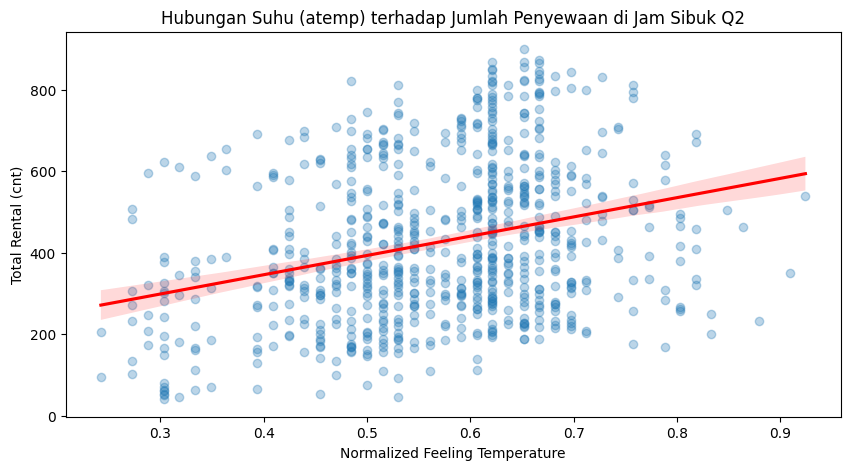

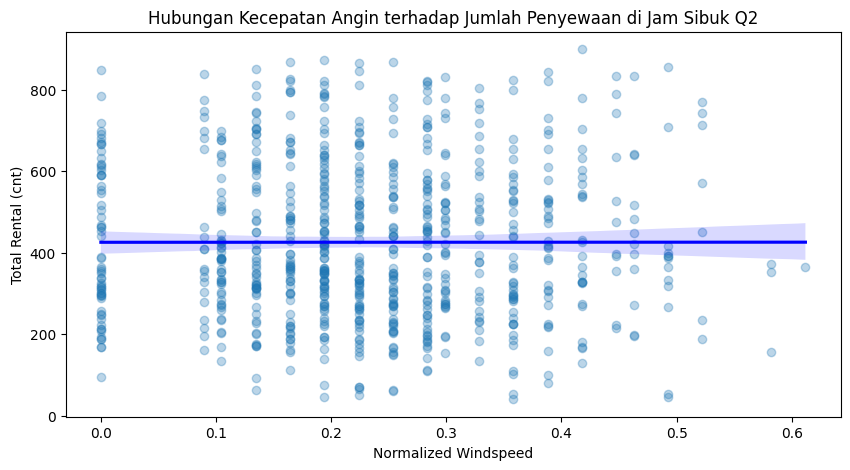

              atemp  windspeed       cnt
atemp      1.000000  -0.022614  0.297466
windspeed -0.022614   1.000000  0.000280
cnt        0.297466   0.000280  1.000000


In [8]:
# Visualisasi Korelasi atemp vs cnt
plt.figure(figsize=(10, 5))
sns.regplot(data=q2_peak_hours, x='atemp', y='cnt', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Hubungan Suhu (atemp) terhadap Jumlah Penyewaan di Jam Sibuk Q2')
plt.xlabel('Normalized Feeling Temperature')
plt.ylabel('Total Rental (cnt)')

# menampilkan diagram
plt.show()

# Visualisasi Korelasi windspeed vs cnt
plt.figure(figsize=(10, 5))
sns.regplot(data=q2_peak_hours, x='windspeed', y='cnt', scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.title('Hubungan Kecepatan Angin terhadap Jumlah Penyewaan di Jam Sibuk Q2')
plt.xlabel('Normalized Windspeed')
plt.ylabel('Total Rental (cnt)')

# menampilkan diagram
plt.show()

# korelasi antara atemp, windspeed, dan cnt
correlation = q2_peak_hours[['atemp', 'windspeed', 'cnt']].corr()
print(correlation)

**Insight:**
- INSIGHT PERTANYAAN 1
- Berdasarkan data selama 12 bulan di tahun 2012, terjadi pola musiman yang konsisten. Permintaan menyentuh titik terendah pada akhir tahun (Desember 2012) dan awal tahun (Januari-Februari 2013) karena faktor cuaca dingin (Winter). Sehingga, Permintaan pada Januari hingga Maret 2013 (Q1 2013) diprediksi akan tetap rendah dan tidak terjadi lonjakan permintaan yang ekstrem.
- Karena permintaan rendah, ini adalah kesempatan untuk melakukan Pemeliharaan. Prioritaskan pemeliharaan rutin, perbaikan unit rusak, dan pengecatan ulang armada.
- Strateginya adalah jangan melakukan pengadaan armada baru di Q1. Gunakan waktu ini untuk memastikan seluruh sepeda dalam kondisi prima sebelum memasuki musim semi (Spring) di mana permintaan mulai menanjak.

- INSIGHT PERTANYAAN 2
- pada bulan januari hingga februari 2012, didominasi oleh Low-Usage day dimana pengguna casual dan registered memiliki aktivitas yang sangat rendah karena sedang terjadi musim dingin.
- pada bulan maret hingga juni 2012, hari-harinya didominasi oleh Commuter day dimana pengguna casual maupun registered mulai beraktivitas penuh karena dimulainya musim semi.
- setiap klaster memiliki kebijakan sebagai pengoptimalan pendapatan dan retensi pengguna
- klaster Leisure-day (hari dimana pengguna casual jauh lebih dominan). Karena mereka menyukai kenyamanan di akhir pekan/hari libur, tawarkan Trial Membership khusus pada bulan-bulan di mana klaster ini tinggi (misalnya April-Juni).
- klaster Commuter-day (hari dimana pengguna registered jauh lebih dominan). Fokus pada ketersediaan armada (supply side). Karena mereka adalah power user, buat kebijakan sistem reward atau tukar poin untuk perpanjang langganan untuk menjaga mereka tetap berlangganan.
- klaster Low-Usage-day (hari dimana aktivitas pengguna sangat rendah). Kebijakan operasional Jangan menaruh sepeda di area terbuka saat musim dingin untuk menghindari kerusakan akibat cuaca, manfaatkan waktu ini untuk pemeliharaan unit-unit sepeda.
- klaster Hybrid-day (hari dimana jumlah pengguna casual dan registered seimbang). Gunakan Hybrid-day untuk mengejar keuntungan. Berikan promo ringan di jam-jam sepi agar tidak terjadi penumpukan dan pastikan kedua segmen mendapatkan pelayanan maksimal.

- INSIGHT PERTANYAAN 3
- Pada Kuartal II (April-Juni), terjadi korelasi positif antara atemp (suhu yang dirasakan) dan cnt (jumlah pesanan), sedangkan atemp dan windspeed (kecepatan angin) memiliki korelasi negatif yang signifikan
- gagasan yang mungkin diterapkan adalah Kebijakan Smart Deployment. Pada hari dengan Suhu Nyaman & Angin Tenang, Perintahkan tim lapangan untuk mendistribusikan sepeda ke titik transportasi utama (stasiun/kantor) 30 menit lebih awal sebelum jam sibuk pagi (07:00).
- jika suatu hari anginnya kencang atau prakiraan cuaca menunjukkan kecepatan angin di atas ambang batas (meskipun suhu hangat), kurangi penempatan sepeda di area terbuka yang berangin. Perintahkan tim lapangan melakukan tugas pemeliharaan atau penyeimbangan armada di area yang lebih terlindungi.

## Analisis Lanjutan (Opsional)

In [9]:
from google.colab import files

# menyimpan di day_cleaned.csv
day_df.to_csv("day_cleaned.csv", index=False)

# menyimpan di hour_cleaned.csv
hour_df.to_csv("hour_cleaned.csv", index=False)

# Mengunduh file day_cleaned.csv
files.download("day_cleaned.csv")

# Mengunduh file hour_cleaned.csv
files.download("hour_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- Kesimpulan pertanyaan 1: pola permintaan cenderung menurun pada akhir tahun 2012 (november - desember) dan tidak terjadi lonjakan permintaan yang ekstrem pada awal tahun 2013 (januari - maret). Pada awal tahun 2013 ini, menjadi kesempatan terbaik untuk melakukan pemeliharaan dan perbaikan Armada sepeda untuk mempersiapkan lonjakan permintaan yang terjadi pada musim semi akhir maret 2013.

- Kesimpulan pertanyaan 2: pada awal tahun 2012 (januari hingga februari) terjadi aktivitas penyewaan yang sangat rendah, pada rentang waktu tersebut strategi yang perlu dilakukan adalah melarang penempatan sepeda di area terbuka agar tidak rusak akibat cuaca dan perintahkan tim lapangan untuk melakukan perawatan unit-unit sepeda. pada rentang bulan maret hingga juni 2012, lebih banyak pengguna registered mulai beraktivitas. pastikan jumlah ketersediaan unit-unit sepeda cukup untuk menunjang aktivitas para pengguna registered, serta terapkan sistem tukar poin untuk menjaga retensi pengguna registered.

- Kesimpulan pertanyaan 3: kondisi cuaca dan musim yang ekstrem seperti kecepatan angin yang tinggi dan suhu udara yang terlalu dingin dapat menurunkan permintaan. strategi yang mungkin dilakukan untuk kondisi cuaca dan musim ini adalah hindari menempatkan sepeda di area terbuka. jika cuaca dan suhu nyaman untuk beraktivitas di luar ruangan, perintahkan tim lapangan untuk mendistribusikan sepeda ke tempat-tempat yang sibuk saat hari kerja di jam 7 pagi hingga jam 6 malam.